# SVM Vegetation Classification
**Task 2**

A Support Vector Machine (SVM) is a supervised machine learning algorithm that acts like a smart divider, creating the best possible line or boundary (hyperplane) to separate different classes of data. It works by maximizing the margin (the widest possible gap) between the closest data points of each group, ensuring accurate classification for new data. 

**Cells:** Load all images → extract pixel features (R,G,B) → stratified sample → train SVM → evaluate

## Cell 1 — Imports & configuration

In [15]:
import os
import numpy as np
import rasterio
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (accuracy_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay)

SAMPLES_DIR = r"../samples"
LABELS_DIR  = r"../labels"

PREFIX_QGA_157 = 'S2A_MSIL2A_20171025T150721_N0500_R082_T19QGA_20230910T203157.SAFE_'
PREFIX_QFA     = 'S2A_MSIL2A_20171224T150711_N0500_R082_T19QFA_20230809T224110.SAFE_'
PREFIX_QGA_110 = 'S2A_MSIL2A_20171224T150711_N0500_R082_T19QGA_20230809T224110.SAFE_'
PREFIX_QHA     = 'S2A_MSIL2A_20171224T150711_N0500_R082_T19QHA_20230809T224110.SAFE_'

PREFIX_QGA_157_IDS = list(range(0, 237))
PREFIX_QFA_IDS     = list(range(0, 53))
PREFIX_QGA_110_IDS = list(range(0, 221))
PREFIX_QHA_IDS     = list(range(0, 103))

CLASS_NAMES  = ['Water/Non-veg', 'Bare Soil', 'Sparse Veg', 'Moderate Veg', 'Dense Veg']
NDVI_BINS    = [0.0, 0.2, 0.4, 0.6]


## Cell 2 Load all 614 images into feature matrix
1. Read **R, G, B** bands → normalize to 0.0–1.0
2. Read the **NDVI label** and rescale to real NDVI (−1 to 1), convert to class **0–4**
3. **Flatten**: each of the 256×256 = 65,536 pixels becomes one row `[R, G, B]`

All tiles are loaded then stacked into one big `X` (features) and `y` (labels) array.

In [18]:
def load_tile(prefix, ids):

    all_X, all_y = [], []

    for count, i in enumerate(ids):
        img_path = os.path.join(SAMPLES_DIR, f'{prefix}img_{i}.tiff')
        lbl_path = os.path.join(LABELS_DIR,  f'{prefix}ndvi_{i}.tiff')

        #load image
        with rasterio.open(img_path) as src:
            r = src.read(1).astype('float32')   # Red band
            g = src.read(2).astype('float32')   # Green band
            b = src.read(3).astype('float32')   # Blue band
        mx = max(r.max(), g.max(), b.max())      # find brightest value
        if mx > 0:
            r, g, b = r / mx, g / mx, b / mx    # normalize to 0.0–1.0

        #load NDVI label and convert to class 0–4
        with rasterio.open(lbl_path) as src:
            ndvi_raw = src.read(1).astype('float32')
        ndvi    = (ndvi_raw - 127.5) / 127.5                     
        cls_map = np.digitize(ndvi, bins=NDVI_BINS).astype(np.uint8) 

        #flatten: (H, W, 3) → (H*W, 3)
        all_X.append(np.stack([r, g, b], axis=-1).reshape(-1, 3))
        all_y.append(cls_map.reshape(-1))

    return np.vstack(all_X), np.hstack(all_y)

tiles = [
    ('QGA_157', PREFIX_QGA_157, PREFIX_QGA_157_IDS),
    ('QFA',     PREFIX_QFA,     PREFIX_QFA_IDS),
    ('QGA_110', PREFIX_QGA_110, PREFIX_QGA_110_IDS),
    ('QHA',     PREFIX_QHA,     PREFIX_QHA_IDS),
]

tile_results = {}
for tile_name, prefix, ids in tiles:
    X_tile, y_tile = load_tile(prefix, ids)
    tile_results[tile_name] = (X_tile, y_tile)

X = np.vstack([v[0] for v in tile_results.values()])
y = np.hstack([v[1] for v in tile_results.values()])

print(f'Total pixels : {X.shape[0]:,}')
print(f'Features     : {X.shape[1]}  (R, G, B values per pixel)')
print(f'\nClass distribution across dataset:')
for c, name in enumerate(CLASS_NAMES):
    n   = (y == c).sum()
    print(f'  {c}  {name:<15} : {n:>10,}  ({100*n/len(y):5.1f}%)')

Total pixels : 40,239,104
Features     : 3  (R, G, B values per pixel)

Class distribution across dataset:
  0  Water/Non-veg   :  2,145,966  (  5.3%)
  1  Bare Soil       :  7,426,542  ( 18.5%)
  2  Sparse Veg      :  9,961,754  ( 24.8%)
  3  Moderate Veg    : 14,355,432  ( 35.7%)
  4  Dense Veg       :  6,349,410  ( 15.8%)


## Cell 3 Stratified sampling, train/test split and feature scaling
**Stratified sampled** 50,000 pixels picking from each class proportionally so
the sample mirrors the real class distribution.

- **80% training set**
- **20% test set**
- **StandardScaler** shifts R, G, B to mean=0, std=1 so larger values dont dominate

In [20]:
SAMPLE_SIZE = 50000
np.random.seed(42)

print(f'Sampling {SAMPLE_SIZE:,} pixels from {X.shape[0]:,} total')
sampled_X, sampled_y = [], []

for cls in range(len(CLASS_NAMES)):
    idx    = np.where(y == cls)[0]                            
    n_take = max(int(SAMPLE_SIZE * len(idx) / len(y)), 50)   
    n_take = min(n_take, len(idx))                         
    chosen = np.random.choice(idx, size=n_take, replace=False)
    sampled_X.append(X[chosen])
    sampled_y.append(y[chosen])
    print(f'  Class {cls}  {CLASS_NAMES[cls]:<15} : sampled {n_take:,}  (from {len(idx):,} available)')

X_s = np.vstack(sampled_X)
y_s = np.hstack(sampled_y)

# 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_s, y_s,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_s
)

#Standard Scaler required for SVM model
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


print(f'\nTraining set : {X_train.shape[0]:,} pixels')
print(f'Test set     : {X_test.shape[0]:,} pixels')
print(f'Features     : {X_train.shape[1]}  (scaled R, G, B)')

Sampling 50,000 pixels from 40,239,104 total
  Class 0  Water/Non-veg   : sampled 2,666  (from 2,145,966 available)
  Class 1  Bare Soil       : sampled 9,228  (from 7,426,542 available)
  Class 2  Sparse Veg      : sampled 12,378  (from 9,961,754 available)
  Class 3  Moderate Veg    : sampled 17,837  (from 14,355,432 available)
  Class 4  Dense Veg       : sampled 7,889  (from 6,349,410 available)

Training set : 39,998 pixels
Test set     : 10,000 pixels
Features     : 3  (scaled R, G, B)


## Cell 4 — Train the SVM
An SVM finds the **optimal boundary** between classes in feature space.

Key parameter:

RBF kernel - Radial Basis Function, handles curved/non-linear class boundaries

In [21]:
print(f'Training SVM on {X_train.shape[0]:,} pixels')

svm = SVC(
    kernel = 'rbf'
)

svm.fit(X_train, y_train)

print('\nTraining complete!')
print(f'Support vectors per class : {svm.n_support_.tolist()}')
print(f'Total support vectors     : {svm.n_support_.sum():,}')

Training SVM on 39,998 pixels

Training complete!
Support vectors per class : [2077, 4905, 8799, 10214, 5516]
Total support vectors     : 31,511


## Cell 5
**Accuracy** - % of all pixels predicted correctly

**Precision** - % of pixels predicted as class X compared with how many truly are X

**Recall** - % of all true class X pixels compared with how many did we find

**F1** - Mean of precision and recall

In [ ]:
y_pred = svm.predict(X_test)

acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score   (y_test, y_pred,)

print('SVM EVALUATION RESULTS')
print()
print(f'  Accuracy  : {acc  * 100:.2f}%')
print(f'  Precision : {prec * 100:.2f}%')
print(f'  Recall    : {rec  * 100:.2f}%')
print()
print('classification eport')
print()
print(classification_report(
    y_test, y_pred,
    target_names  = CLASS_NAMES,
    zero_division = 0
))

SVM EVALUATION RESULTS
  Accuracy  : 67.97%
  Precision : 68.22%
  Recall    : 67.97%

PER-CLASS BREAKDOWN
               precision    recall  f1-score   support

Water/Non-veg       0.59      0.17      0.26       533
    Bare Soil       0.72      0.65      0.69      1846
   Sparse Veg       0.61      0.76      0.68      2476
 Moderate Veg       0.71      0.78      0.74      3567
    Dense Veg       0.72      0.53      0.61      1578

     accuracy                           0.68     10000
    macro avg       0.67      0.58      0.60     10000
 weighted avg       0.68      0.68      0.67     10000



## Cell 6 Confusion matrix
Rows = true class 

Columns = predicted class

**Diagonal** = correct predictions

**Off-diagonal** = mistakes

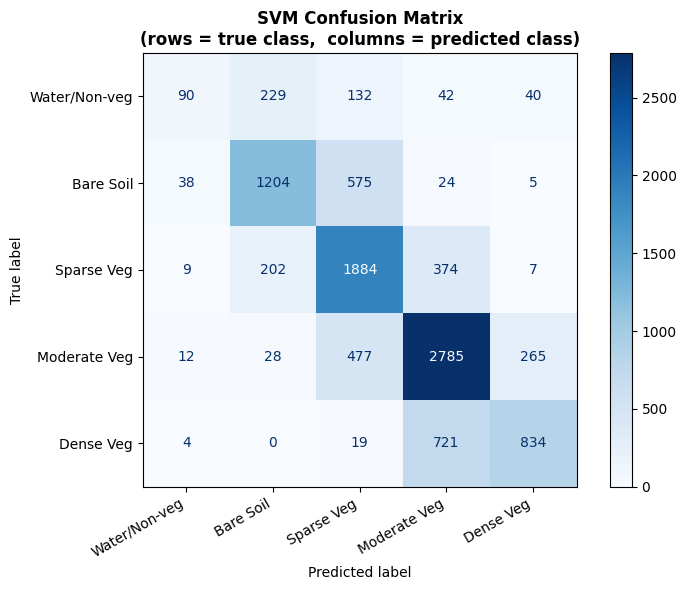

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels = CLASS_NAMES,
    cmap           = 'Blues',
    ax             = ax
)
ax.set_title('SVM Confusion Matrix\n(rows = true class,  columns = predicted class)',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
total_images = (len(PREFIX_QGA_157_IDS) + len(PREFIX_QFA_IDS) +
                len(PREFIX_QGA_110_IDS) + len(PREFIX_QHA_IDS))

print('TASK 2 — FINAL SUMMARY')
print()
print(f'  Total images               : {total_images:>4}')
print(f'  Total pixels               : {X.shape[0]:,}')
print(f'  Sampled for SVM            : {X_s.shape[0]:,}  (stratified)')
print(f'  Train / Test split         : {X_train.shape[0]:,} / {X_test.shape[0]:,}')
print(f'  Model                      : SVM (kernel=rbf')
print(f'  Features per pixel         : 3  (R, G, B)')
print()
print(f'  Accuracy  : {acc  * 100:.2f}%')
print(f'  Precision : {prec * 100:.2f}%')
print(f'  Recall    : {rec  * 100:.2f}%')

TASK 2 — FINAL SUMMARY

  QGA_157  (img_0 – img_236) :  237 images
  QFA      (img_0 – img_52)  :   53 images
  QGA_110  (img_0 – img_220) :  221 images
  QHA      (img_0 – img_102) :  103 images
  Total images               :  614
  Total pixels               : 40,239,104
  Sampled for SVM            : 49,998  (stratified)
  Train / Test split         : 39,998 / 10,000
  Model                      : SVM (kernel=rbf
  Features per pixel         : 3  (R, G, B)

  Accuracy  : 67.97%
  Precision : 68.22%
  Recall    : 67.97%

  Why we move to CNN next:
  → SVM sees only 3 RGB values per pixel — no spatial context
  → CNN learns from pixel patches — captures edges, textures, shapes
  → CNN scales better with 600+ images and all spectral bands
